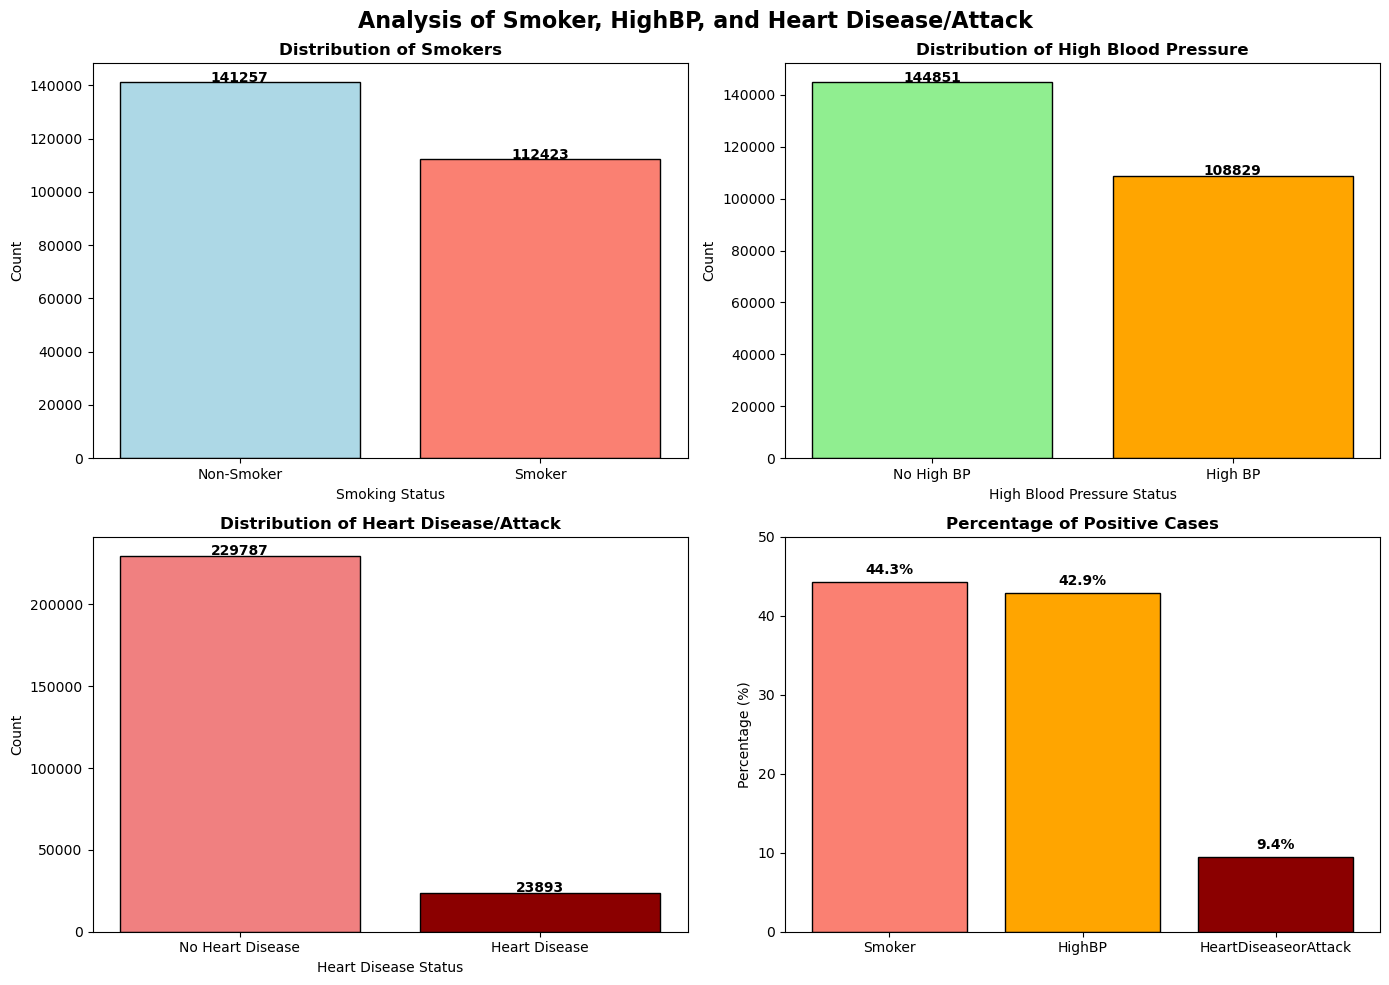

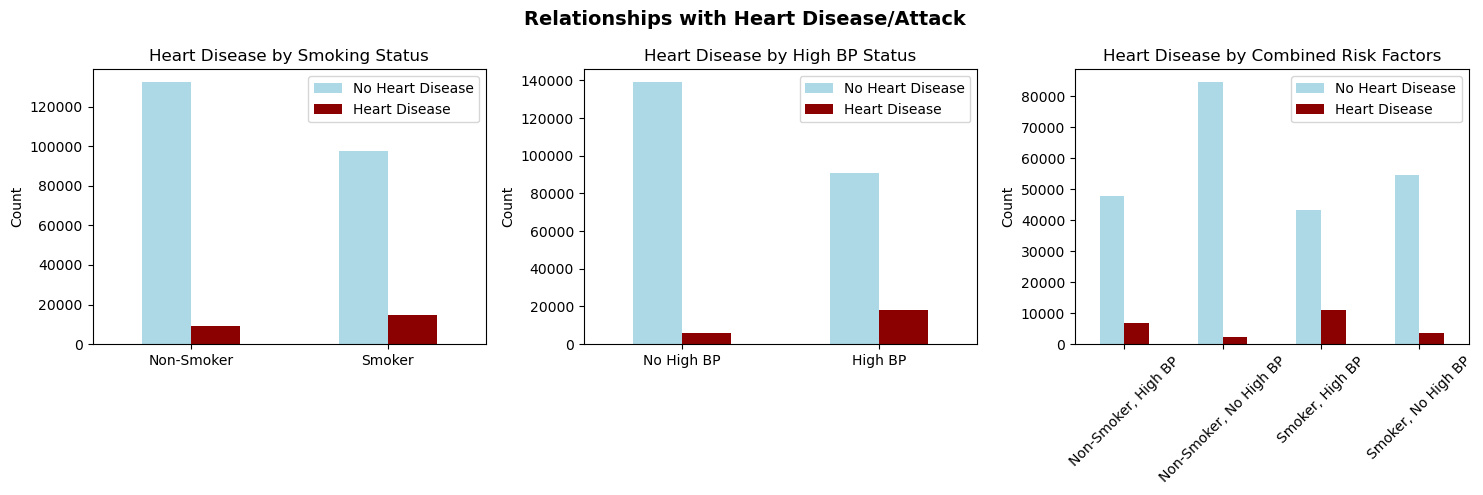

RISK ANALYSIS

Heart Disease Rate in Smokers: 13.17%
Heart Disease Rate in Non-Smokers: 6.44%
Risk Ratio (Smoker vs Non-Smoker): 2.05

Heart Disease Rate in High BP: 16.47%
Heart Disease Rate in Normal BP: 4.12%
Risk Ratio (High BP vs Normal BP): 4.00

Heart Disease Rate by Risk Factors:
  Non-Smoker, Normal BP: 2.67%
  Non-Smoker, High BP: 12.43%
  Smoker, Normal BP: 6.28%
  Smoker, High BP: 20.54%


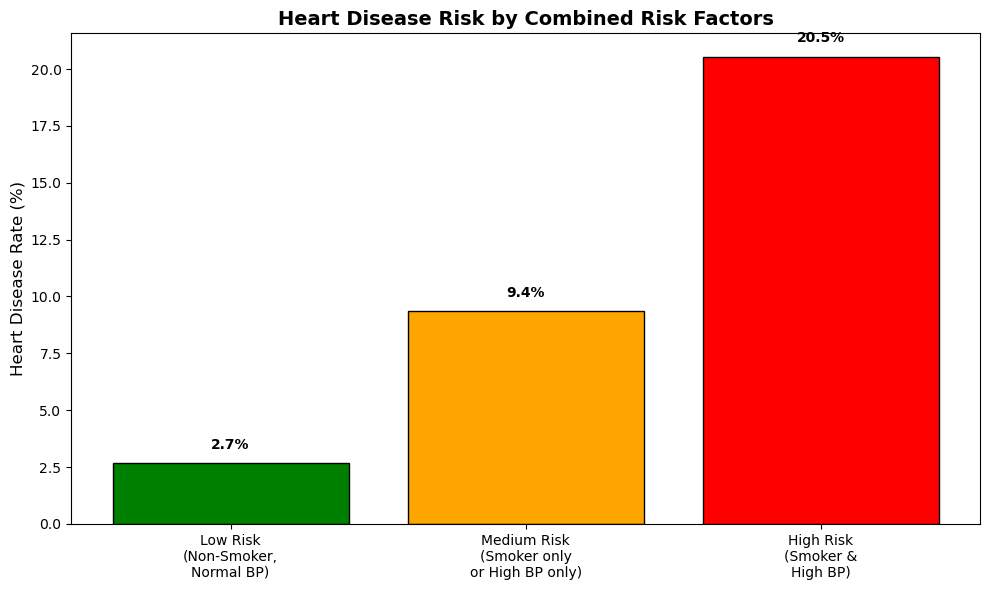


KEY FINDINGS:
• 13.2% of smokers have heart disease vs 6.4% of non-smokers
• 16.5% of people with high BP have heart disease vs 4.1% with normal BP
• People with BOTH smoking and high BP have 20.5% heart disease rate
• That's 7.7x higher than those with neither risk factor


In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('data.csv')

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analysis of Smoker, HighBP, and Heart Disease/Attack', fontsize=16, fontweight='bold')

# 1. Distribution of Smoker
smoker_counts = df['Smoker'].value_counts()
axes[0, 0].bar(['Non-Smoker', 'Smoker'], smoker_counts.values, 
                color=['lightblue', 'salmon'], edgecolor='black')
axes[0, 0].set_title('Distribution of Smokers', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Smoking Status')
for i, v in enumerate(smoker_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Distribution of HighBP
bp_counts = df['HighBP'].value_counts()
axes[0, 1].bar(['No High BP', 'High BP'], bp_counts.values,
                color=['lightgreen', 'orange'], edgecolor='black')
axes[0, 1].set_title('Distribution of High Blood Pressure', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('High Blood Pressure Status')
for i, v in enumerate(bp_counts.values):
    axes[0, 1].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 3. Distribution of Heart Disease/Attack
heart_counts = df['HeartDiseaseorAttack'].value_counts()
axes[1, 0].bar(['No Heart Disease', 'Heart Disease'], heart_counts.values,
                color=['lightcoral', 'darkred'], edgecolor='black')
axes[1, 0].set_title('Distribution of Heart Disease/Attack', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Heart Disease Status')
for i, v in enumerate(heart_counts.values):
    axes[1, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 4. Percentage distribution
categories = ['Smoker', 'HighBP', 'HeartDiseaseorAttack']
percentages = []
for cat in categories:
    counts = df[cat].value_counts()
    percentages.append(counts[1] / len(df) * 100)

axes[1, 1].bar(categories, percentages, color=['salmon', 'orange', 'darkred'], edgecolor='black')
axes[1, 1].set_title('Percentage of Positive Cases', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_ylim(0, 50)
for i, v in enumerate(percentages):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Create additional plot: Relationship between variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Relationships with Heart Disease/Attack', fontsize=14, fontweight='bold')

# 1. Heart Disease by Smoking Status
heart_by_smoker = pd.crosstab(df['Smoker'], df['HeartDiseaseorAttack'])
heart_by_smoker.columns = ['No Heart Disease', 'Heart Disease']
heart_by_smoker.index = ['Non-Smoker', 'Smoker']
heart_by_smoker.plot(kind='bar', ax=axes[0], color=['lightblue', 'darkred'])
axes[0].set_title('Heart Disease by Smoking Status', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].legend(title='')
axes[0].tick_params(axis='x', rotation=0)

# 2. Heart Disease by HighBP Status
heart_by_bp = pd.crosstab(df['HighBP'], df['HeartDiseaseorAttack'])
heart_by_bp.columns = ['No Heart Disease', 'Heart Disease']
heart_by_bp.index = ['No High BP', 'High BP']
heart_by_bp.plot(kind='bar', ax=axes[1], color=['lightblue', 'darkred'])
axes[1].set_title('Heart Disease by High BP Status', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].legend(title='')
axes[1].tick_params(axis='x', rotation=0)

# 3. Heart Disease by Smoker & HighBP Combined
df['Smoker_HighBP'] = df['Smoker'].astype(str) + '_' + df['HighBP'].astype(str)
smoker_bp_labels = {
    '0_0': 'Non-Smoker, No High BP',
    '0_1': 'Non-Smoker, High BP',
    '1_0': 'Smoker, No High BP',
    '1_1': 'Smoker, High BP'
}
df['Smoker_HighBP_Label'] = df['Smoker_HighBP'].map(smoker_bp_labels)
heart_by_combined = pd.crosstab(df['Smoker_HighBP_Label'], df['HeartDiseaseorAttack'])
heart_by_combined.columns = ['No Heart Disease', 'Heart Disease']
heart_by_combined.plot(kind='bar', ax=axes[2], color=['lightblue', 'darkred'])
axes[2].set_title('Heart Disease by Combined Risk Factors', fontsize=12)
axes[2].set_ylabel('Count')
axes[2].set_xlabel('')
axes[2].legend(title='')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate risk ratios
print("="*60)
print("RISK ANALYSIS")
print("="*60)

# Heart Disease rate in smokers vs non-smokers
heart_smoker = df[df['Smoker'] == 1]['HeartDiseaseorAttack'].mean() * 100
heart_non_smoker = df[df['Smoker'] == 0]['HeartDiseaseorAttack'].mean() * 100
print(f"\nHeart Disease Rate in Smokers: {heart_smoker:.2f}%")
print(f"Heart Disease Rate in Non-Smokers: {heart_non_smoker:.2f}%")
print(f"Risk Ratio (Smoker vs Non-Smoker): {heart_smoker/heart_non_smoker:.2f}")

# Heart Disease rate in high BP vs normal BP
heart_highbp = df[df['HighBP'] == 1]['HeartDiseaseorAttack'].mean() * 100
heart_normalbp = df[df['HighBP'] == 0]['HeartDiseaseorAttack'].mean() * 100
print(f"\nHeart Disease Rate in High BP: {heart_highbp:.2f}%")
print(f"Heart Disease Rate in Normal BP: {heart_normalbp:.2f}%")
print(f"Risk Ratio (High BP vs Normal BP): {heart_highbp/heart_normalbp:.2f}")

# Combined risk
df_combined = df.groupby(['Smoker', 'HighBP'])['HeartDiseaseorAttack'].mean() * 100
print(f"\nHeart Disease Rate by Risk Factors:")
for (smoker, bp), rate in df_combined.items():
    smoker_text = "Smoker" if smoker else "Non-Smoker"
    bp_text = "High BP" if bp else "Normal BP"
    print(f"  {smoker_text}, {bp_text}: {rate:.2f}%")

# Create a stacked bar chart for risk levels
fig, ax = plt.subplots(figsize=(10, 6))
risk_levels = ['Low Risk\n(Non-Smoker,\nNormal BP)', 
               'Medium Risk\n(Smoker only\nor High BP only)', 
               'High Risk\n(Smoker &\nHigh BP)']

low_risk = df[(df['Smoker'] == 0) & (df['HighBP'] == 0)]['HeartDiseaseorAttack'].mean() * 100
medium_risk_smoker = df[(df['Smoker'] == 1) & (df['HighBP'] == 0)]['HeartDiseaseorAttack'].mean() * 100
medium_risk_bp = df[(df['Smoker'] == 0) & (df['HighBP'] == 1)]['HeartDiseaseorAttack'].mean() * 100
medium_risk = (medium_risk_smoker + medium_risk_bp) / 2
high_risk = df[(df['Smoker'] == 1) & (df['HighBP'] == 1)]['HeartDiseaseorAttack'].mean() * 100

risk_rates = [low_risk, medium_risk, high_risk]
colors = ['green', 'orange', 'red']

bars = ax.bar(risk_levels, risk_rates, color=colors, edgecolor='black')
ax.set_ylabel('Heart Disease Rate (%)', fontsize=12)
ax.set_title('Heart Disease Risk by Combined Risk Factors', fontsize=14, fontweight='bold')

for bar, rate in zip(bars, risk_rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
print(f"• {heart_smoker:.1f}% of smokers have heart disease vs {heart_non_smoker:.1f}% of non-smokers")
print(f"• {heart_highbp:.1f}% of people with high BP have heart disease vs {heart_normalbp:.1f}% with normal BP")
print(f"• People with BOTH smoking and high BP have {high_risk:.1f}% heart disease rate")
print(f"• That's {high_risk/low_risk:.1f}x higher than those with neither risk factor")

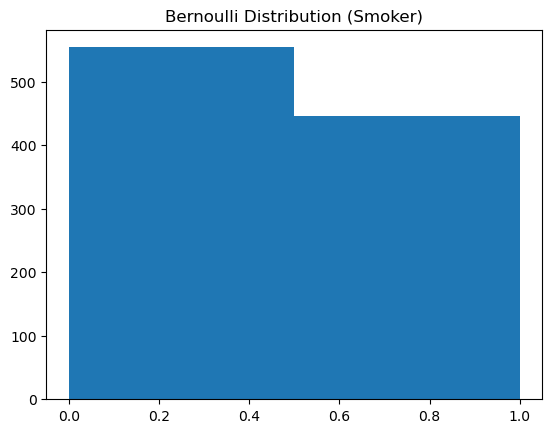

In [104]:
from scipy.stats import bernoulli
import matplotlib.pyplot as plt
import pandas as pd
df=pd.read_csv('data.csv')

p = df['Smoker'].mean()

sample = bernoulli.rvs(p, size=1000)

plt.hist(sample, bins=2)
plt.title("Bernoulli Distribution (Smoker)")
plt.show()

🔹 1. Bernoulli (Smoker)

 Used for binary data (0 or 1)

 Here: Smoker → Yes (1) or No (0)
 
 👉 Models probability of being a smoker

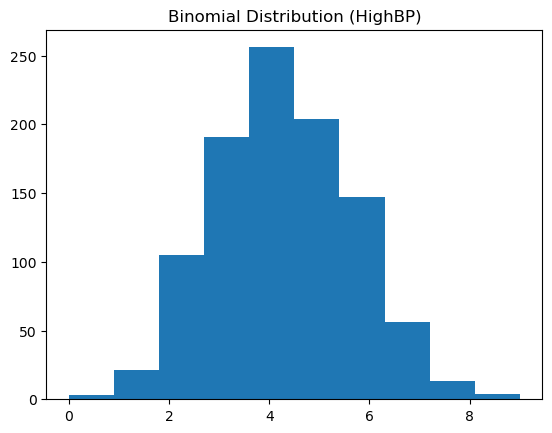

In [105]:
from scipy.stats import binom
import numpy as np

p = df['HighBP'].mean()
n = 10  # number of trials

sample = binom.rvs(n, p, size=1000)

plt.hist(sample, bins=10)
plt.title("Binomial Distribution (HighBP)")
plt.show()

🔹 2. Binomial (HighBP)

Used for multiple Bernoulli trials

Here: “Out of 10 people, how many have high BP?”

👉 Counts number of successes in repeated trials

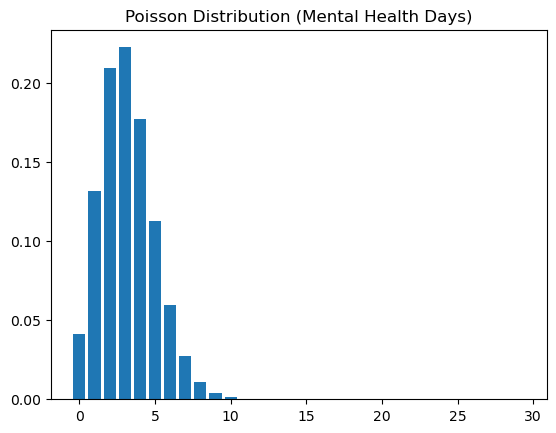

In [106]:
from scipy.stats import poisson

lam = df['MentHlth'].mean()

x = np.arange(0, 30)
y = poisson.pmf(x, lam)

plt.bar(x, y)
plt.title("Poisson Distribution (Mental Health Days)")
plt.show()

🔹 3. Poisson (MentHlth)

Used for count data (events in a period)

Here: number of bad mental health days

👉 Models how often events occur

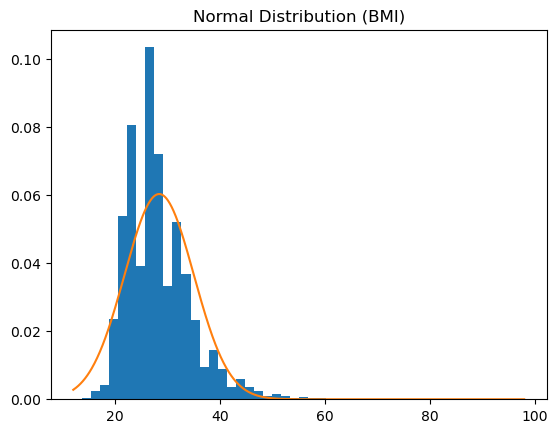

In [107]:
from scipy.stats import norm

mean = df['BMI'].mean()
std = df['BMI'].std()

x = np.linspace(df['BMI'].min(), df['BMI'].max(), 1000)
y = norm.pdf(x, mean, std)

plt.hist(df['BMI'], bins=50, density=True)
plt.plot(x, y)
plt.title("Normal Distribution (BMI)")
plt.show()

🔹 4. Normal (BMI)

Used for continuous data

Here: BMI values

👉 Shows natural spread around mean (bell curve)

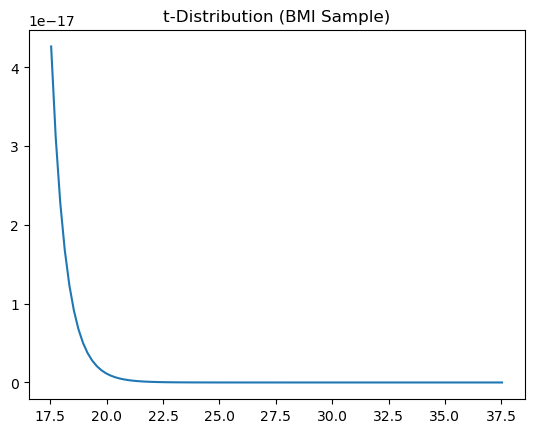

In [108]:
from scipy.stats import t

sample = df['BMI'].sample(30)

mean = sample.mean()
std = sample.std()
dfree = len(sample) - 1

x = np.linspace(mean-10, mean+10, 100)
y = t.pdf(x, dfree)

plt.plot(x, y)
plt.title("t-Distribution (BMI Sample)")
plt.show()

🔹 5. t-Distribution (BMI sample)

Used when sample size is small

Here: sample of BMI (e.g., 30 values)

👉 Similar to normal but accounts for uncertainty

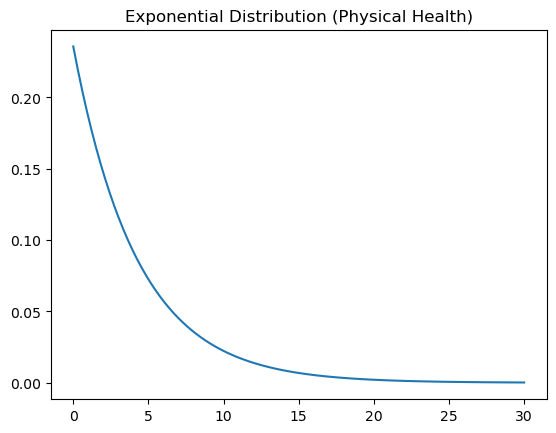

In [109]:
from scipy.stats import expon

scale = df['PhysHlth'].mean()

x = np.linspace(0, 30, 100)
y = expon.pdf(x, scale=scale)

plt.plot(x, y)
plt.title("Exponential Distribution (Physical Health)")
plt.show()

🔹 6. Exponential (PhysHlth)

Used for time between events

Here: days of poor physical health

👉 Models waiting time between events

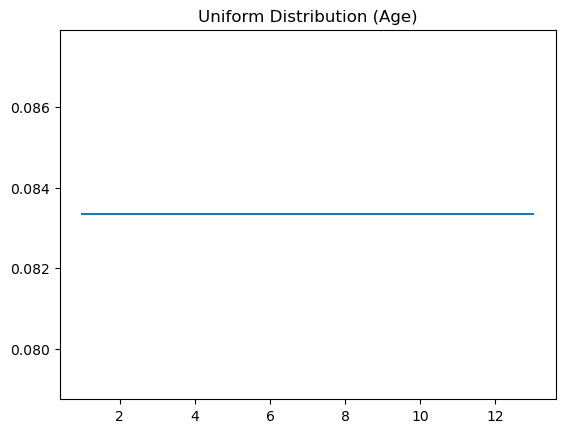

In [110]:
from scipy.stats import uniform

a = df['Age'].min()
b = df['Age'].max()

x = np.linspace(a, b, 100)
y = uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, y)
plt.title("Uniform Distribution (Age)")
plt.show()

🔹 7. Uniform (Age)

Used when all values are equally likely

Here: age categories (assumed evenly spread)

👉 No bias, equal probability everywhere

***🎯 One-Line Summary***

Each distribution is chosen based on data type:

Binary → Bernoulli

Counts → Poisson

Continuous → Normal

Small sample → t

Time gaps → Exponential
Equal spread → Uniform